# This is to check which of the common DEG's across visits are statistically significant and also express similar regulation patterns
___
Also, this notebook shall help to sketch out a solution that can be immediately applied in a batch script for all strata.

In [1]:
import pandas as pd

In [2]:
results_path = "/Users/kpax/Documents/aep/study/MSC/lab/PPMI_Project_133_RNASeq/dge_stratified/results/common_genes_across_visits_Male_50-70.csv"

In [5]:
common_genes_across_visits_male_50_70 = pd.read_csv(results_path, index_col=0)

In [6]:
common_genes_across_visits_male_50_70.head()

,BL,BL_padj,V02,V02_padj,V04,V04_padj,V06,V06_padj,V08,V08_padj,BL_log2FC,V02_log2FC,V04_log2FC,V06_log2FC,V08_log2FC,gene_symbol,trunc_eid
ENSG00000229807.11,True,2.889045e-09,True,0.686807,True,NaN,True,0.002295,True,0.999979,-2.958401,-0.222043,0.263157,-2.371949,-1.220696,XIST,ENSG00000229807
ENSG00000185640.5,True,2.749162e-06,True,0.060377,True,NaN,True,NaN,True,0.000001,-1.456439,-0.699316,-1.241380,-1.062653,-1.750941,KRT79,ENSG00000185640
ENSG00000243366.3,True,9.611061e-05,True,0.057186,True,NaN,True,NaN,True,0.999979,2.539189,1.108403,0.738620,0.089709,0.113926,RN7SL60P,ENSG00000243366
ENSG00000199883.1,True,9.611061e-05,True,0.896629,True,NaN,True,NaN,True,0.799606,-1.999717,0.107016,-1.803415,-0.428330,-1.293501,RN7SKP90,ENSG00000199883
ENSG00000239710.3,True,1.479627e-04,True,0.049420,True,NaN,True,NaN,True,0.999979,-1.998197,1.270067,0.027251,-0.654642,-0.124122,RN7SL692P,ENSG00000239710


In [9]:
filtered_genes = common_genes_across_visits_male_50_70[
    (common_genes_across_visits_male_50_70['BL_padj'] <= 0.05) &
    (common_genes_across_visits_male_50_70['V02_padj'] <= 0.05) &
    (common_genes_across_visits_male_50_70['V04_padj'] <= 0.05) &
    (common_genes_across_visits_male_50_70['V06_padj'] <= 0.05) &
    (common_genes_across_visits_male_50_70['V08_padj'] <= 0.05) &
    (common_genes_across_visits_male_50_70['BL_log2FC'].abs() >= 0.5) &
    (common_genes_across_visits_male_50_70['V02_log2FC'].abs() >= 0.5) &
    (common_genes_across_visits_male_50_70['V04_log2FC'].abs() >= 0.5) &
    (common_genes_across_visits_male_50_70['V06_log2FC'].abs() >= 0.5) &
    (common_genes_across_visits_male_50_70['V08_log2FC'].abs() >= 0.5)
]

In [11]:
if filtered_genes.empty:
    print("There aren't any similarities regarding fold change and padj across visits")
else:
    print(f"Similarities exist for the following genes: {filtered_genes.index.tolist()}")

There aren't any similarities regarding fold change and padj across visits


In [15]:
filtered_genes = common_genes_across_visits_male_50_70[
    ((common_genes_across_visits_male_50_70[['BL_padj', 'V02_padj', 'V04_padj', 'V06_padj', 'V08_padj']] <= 0.05).sum(axis=1) >= 2) &
    ((common_genes_across_visits_male_50_70[['BL_log2FC', 'V02_log2FC', 'V04_log2FC', 'V06_log2FC', 'V08_log2FC']].abs() >= 0.5).sum(axis=1) >= 2)
]

In [16]:
filtered_genes.head()

,BL,BL_padj,V02,V02_padj,V04,V04_padj,V06,V06_padj,V08,V08_padj,BL_log2FC,V02_log2FC,V04_log2FC,V06_log2FC,V08_log2FC,gene_symbol,trunc_eid
ENSG00000229807.11,True,2.889045e-09,True,0.686807,True,NaN,True,0.002295,True,9.999787e-01,-2.958401,-0.222043,0.263157,-2.371949,-1.220696,XIST,ENSG00000229807
ENSG00000185640.5,True,2.749162e-06,True,0.060377,True,NaN,True,NaN,True,1.306008e-06,-1.456439,-0.699316,-1.241380,-1.062653,-1.750941,KRT79,ENSG00000185640
ENSG00000239710.3,True,1.479627e-04,True,0.049420,True,NaN,True,NaN,True,9.999787e-01,-1.998197,1.270067,0.027251,-0.654642,-0.124122,RN7SL692P,ENSG00000239710
ENSG00000207005.1,True,6.162995e-04,True,0.037252,True,0.819676,True,0.999447,True,9.999787e-01,-1.394378,0.499235,0.613675,0.122249,0.018431,RNU1-2,ENSG00000207005
ENSG00000207110.1,True,4.088776e-03,True,0.936640,True,NaN,True,NaN,True,2.176773e-07,-0.753683,-0.013943,-1.384043,-1.318623,-1.582467,RNVU1-32,ENSG00000207110


In [17]:
common_genes_across_visits_male_50_70 = common_genes_across_visits_male_50_70.dropna()

In [18]:
common_genes_across_visits_male_50_70.shape

(10730, 17)

In [20]:
common_genes_across_visits_male_50_70

,BL,BL_padj,V02,V02_padj,V04,V04_padj,V06,V06_padj,V08,V08_padj,BL_log2FC,V02_log2FC,V04_log2FC,V06_log2FC,V08_log2FC,gene_symbol,trunc_eid
ENSG00000207005.1,True,0.000616,True,0.037252,True,0.819676,True,0.999447,True,0.999979,-1.394378,0.499235,0.613675,0.122249,0.018431,RNU1-2,ENSG00000207005
ENSG00000154146.12,True,0.001376,True,0.987454,True,0.999521,True,0.440981,True,0.999979,-0.660539,-0.003391,-0.204988,-0.241854,-0.372657,NRGN,ENSG00000154146
ENSG00000228549.3,True,0.011046,True,0.091704,True,0.999521,True,0.045601,True,0.999979,2.358082,0.755800,-0.374087,2.327700,1.561304,LINC03126,ENSG00000228549
ENSG00000226067.6,True,0.021972,True,0.037252,True,0.085802,True,0.137826,True,0.158423,0.250830,0.243009,0.183651,0.193585,0.249702,LINC00623,ENSG00000226067
ENSG00000074416.14,True,0.037441,True,0.332315,True,0.746498,True,0.966339,True,0.999979,-0.330450,-0.106101,-0.192732,-0.086607,-0.214649,MGLL,ENSG00000074416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000101150.17,True,0.999659,True,0.969851,True,0.999521,True,0.944627,True,0.999979,0.000020,0.001888,-0.012049,-0.038664,0.029012,TPD52L2,ENSG00000101150
ENSG00000126746.17,True,0.999889,True,0.053842,True,0.999521,True,0.999447,True,0.999979,0.000007,-0.087945,-0.003123,-0.021426,-0.031090,ZNF384,ENSG00000126746
ENSG00000213380.15,True,0.999889,True,0.286025,True,0.999521,True,0.999447,True,0.999979,0.000005,0.030481,0.019255,-0.016130,0.037614,COG8,ENSG00000213380
ENSG00000201998.1,True,0.999977,True,0.289039,True,0.999521,True,0.999447,True,0.999979,-0.000005,0.166228,-0.046873,0.046218,0.130102,SNORA23,ENSG00000201998


In [22]:
feature_selection_path = "/Users/kpax/Documents/aep/study/MSC/lab/PPMI_Project_133_RNASeq/classification/"
fs_bl = pd.read_csv(f"{feature_selection_path}/common_genes_Male_50-70_BL.csv", index_col=0)
fs_v02 = pd.read_csv(f"{feature_selection_path}/common_genes_Male_50-70_V02.csv", index_col=0)
fs_v04 = pd.read_csv(f"{feature_selection_path}/common_genes_Male_50-70_V04.csv", index_col=0)
fs_v06 = pd.read_csv(f"{feature_selection_path}/common_genes_Male_50-70_V06.csv", index_col=0)
fs_v08 = pd.read_csv(f"{feature_selection_path}/common_genes_Male_50-70_V08.csv", index_col=0)

fs_bl: 716 common genes
fs_v02: 3 common genes
fs_v04: 431 common genes
fs_v06: 70 common genes
fs_v08: 2 common genes


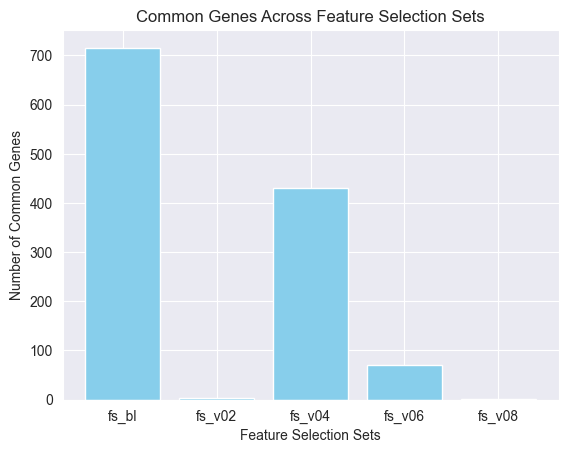

In [25]:
import matplotlib.pyplot as plt

common_counts = {
    "fs_bl": len(common_genes_across_visits_male_50_70.index.intersection(fs_bl.index)),
    "fs_v02": len(common_genes_across_visits_male_50_70.index.intersection(fs_v02.index)),
    "fs_v04": len(common_genes_across_visits_male_50_70.index.intersection(fs_v04.index)),
    "fs_v06": len(common_genes_across_visits_male_50_70.index.intersection(fs_v06.index)),
    "fs_v08": len(common_genes_across_visits_male_50_70.index.intersection(fs_v08.index))
}

# Print the counts
for key, count in common_counts.items():
    print(f"{key}: {count} common genes")

# Create a bar plot
plt.bar(common_counts.keys(), common_counts.values(), color='skyblue')
plt.xlabel('Feature Selection Sets')
plt.ylabel('Number of Common Genes')
plt.title('Common Genes Across Feature Selection Sets')
plt.show()

In [26]:
filtered_by_fs_bl = common_genes_across_visits_male_50_70.loc[common_genes_across_visits_male_50_70.index.intersection(fs_bl.index)]

In [29]:
filtered_by_fs_bl = filtered_by_fs_bl.sort_values(by=['BL_padj', 'BL_log2FC'], ascending=[True, False])

In [30]:
filtered_by_fs_bl

,BL,BL_padj,V02,V02_padj,V04,V04_padj,V06,V06_padj,V08,V08_padj,BL_log2FC,V02_log2FC,V04_log2FC,V06_log2FC,V08_log2FC,gene_symbol,trunc_eid
ENSG00000180953.11,True,0.087888,True,0.756938,True,0.999521,True,0.976431,True,0.999979,0.158832,-0.019725,0.061941,0.040613,0.107529,ST20,ENSG00000180953
ENSG00000166801.15,True,0.099401,True,0.642606,True,0.999521,True,0.919428,True,0.999979,0.119694,0.017882,0.028059,0.038820,0.037338,FAM111A,ENSG00000166801
ENSG00000188321.13,True,0.103781,True,0.321911,True,0.999521,True,0.440981,True,0.999979,0.136094,0.063714,0.063081,0.104211,0.084939,ZNF559,ENSG00000188321
ENSG00000115604.10,True,0.110034,True,0.242358,True,0.999521,True,0.953624,True,0.999979,0.196638,0.088995,0.018657,0.059219,0.125956,IL18R1,ENSG00000115604
ENSG00000135828.11,True,0.110719,True,0.393947,True,0.999521,True,0.999447,True,0.999979,0.112278,0.035973,0.007623,0.013071,0.089826,RNASEL,ENSG00000135828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000146776.14,True,0.992631,True,0.226701,True,0.999521,True,0.969124,True,0.999979,0.000593,-0.057282,0.003568,0.033316,-0.018605,ATXN7L1,ENSG00000146776
ENSG00000164124.10,True,0.992631,True,0.377353,True,0.999521,True,0.999447,True,0.999979,-0.001081,-0.078726,0.022508,0.016399,-0.014324,TMEM144,ENSG00000164124
ENSG00000180871.7,True,0.994250,True,0.218101,True,0.885630,True,0.996436,True,0.999979,-0.000709,-0.090973,-0.099054,-0.044988,-0.002712,CXCR2,ENSG00000180871
ENSG00000117899.10,True,0.995086,True,0.486475,True,0.999521,True,0.999447,True,0.999979,-0.000233,-0.020473,-0.007538,0.010859,-0.018442,MESD,ENSG00000117899


In [31]:
filtered_by_fs_v04 = common_genes_across_visits_male_50_70.loc[common_genes_across_visits_male_50_70.index.intersection(fs_v04.index)]

In [32]:
filtered_by_fs_v04 = filtered_by_fs_v04.sort_values(by=['BL_padj', 'BL_log2FC'], ascending=[True, False])


In [33]:
filtered_by_fs_v04

,BL,BL_padj,V02,V02_padj,V04,V04_padj,V06,V06_padj,V08,V08_padj,BL_log2FC,V02_log2FC,V04_log2FC,V06_log2FC,V08_log2FC,gene_symbol,trunc_eid
ENSG00000172366.19,True,0.078753,True,0.277428,True,0.999521,True,0.999447,True,0.999979,-0.192236,0.067529,0.042011,0.017300,0.059265,MCRIP2,ENSG00000172366
ENSG00000180953.11,True,0.087888,True,0.756938,True,0.999521,True,0.976431,True,0.999979,0.158832,-0.019725,0.061941,0.040613,0.107529,ST20,ENSG00000180953
ENSG00000165071.14,True,0.109666,True,0.474314,True,0.999521,True,0.883172,True,0.999979,0.109988,0.031222,0.011247,0.050444,0.064881,TMEM71,ENSG00000165071
ENSG00000115604.10,True,0.110034,True,0.242358,True,0.999521,True,0.953624,True,0.999979,0.196638,0.088995,0.018657,0.059219,0.125956,IL18R1,ENSG00000115604
ENSG00000254634.4,True,0.111070,True,0.235801,True,0.999521,True,0.624863,True,0.999979,0.244795,0.138538,0.116188,0.169443,0.161767,SMG1P6,ENSG00000254634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000165312.6,True,0.988028,True,0.083368,True,0.999521,True,0.999447,True,0.999979,0.001118,0.094669,0.041794,0.033546,0.065940,OTUD1,ENSG00000165312
ENSG00000181817.5,True,0.988190,True,0.943567,True,0.999521,True,0.957684,True,0.999979,-0.001058,0.004048,0.021757,-0.041107,0.026582,LSM10,ENSG00000181817
ENSG00000243650.3,True,0.990824,True,0.234148,True,0.999521,True,0.999447,True,0.999979,-0.001068,-0.064771,0.027305,0.023087,0.019357,RN7SL834P,ENSG00000243650
ENSG00000139055.6,True,0.992631,True,0.053294,True,0.999521,True,0.970549,True,0.999979,-0.000703,-0.122441,0.027814,0.044278,-0.000757,ERP27,ENSG00000139055
